## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [1]:
# Load dataset:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

# Preview dataset:
df.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


In [2]:
# View summary:
df.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


In [3]:
# View info:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    str    
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 9.2 KB


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [7]:
# Convert data to tidy format:
# Tidy format rules:
# 1. Each variable has its own column.
# 2. Each observation has its own row.
# 3. Each type of observation has its own table.
df_tidy = df.melt(
    id_vars="country", # Columns that should be kept (repeated each row in tidy format).
    value_vars=["beer_servings", "spirit_servings", "wine_servings"], # Specify that we want to drop total_litres_of_pure_alcohol.
    var_name="drink", # Name of the new column that will store original column names.
    value_name="servings" # Name of the new column that will store original column values.
)

# View results:
df_tidy.head(10)

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
5,Antigua & Barbuda,beer_servings,102
6,Argentina,beer_servings,193
7,Armenia,beer_servings,21
8,Australia,beer_servings,261
9,Austria,beer_servings,279


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [8]:
# Remove "_servings" from the tidy dataframe:
df_tidy["drink"] = df_tidy["drink"].str.replace("_servings", "", regex=False)

# View results:
df_tidy.head()

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217


In [9]:
# Imports:
import seaborn as sns
import matplotlib.pyplot as plt

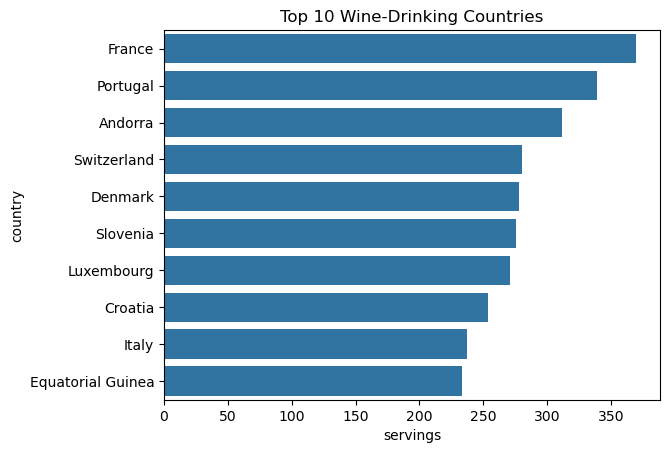

In [10]:
# Categorical plot #1: Who drinks the most wine?
# Sort for the top 10 wine-drinking countries:
top_10_wine = (
    df_tidy[df_tidy["drink"] == "wine"]
    .sort_values(by="servings", ascending=False)
    .head(10)
)

# Plot:
sns.barplot(data=top_10_wine, x="servings", y="country")
plt.title("Top 10 Wine-Drinking Countries")
plt.show()

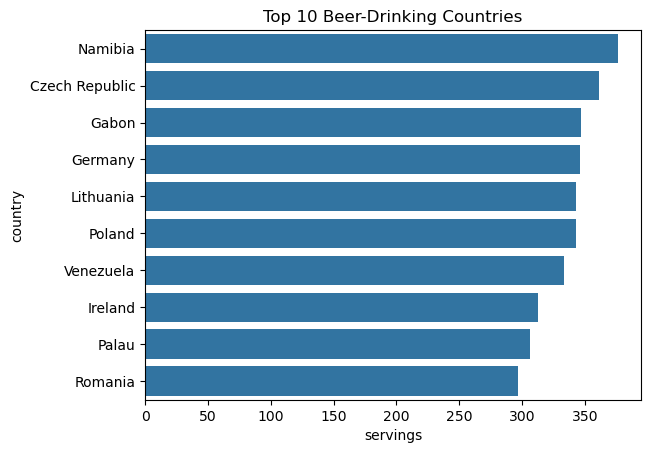

In [12]:
# Categorical plot #2: Who drinks the most beer?
# Sort for the top 10 beer-drinking countries:
top_10_beer = (
    df_tidy[df_tidy["drink"] == "beer"]
    .sort_values(by="servings", ascending=False)
    .head(10)
)

# Plot: 
sns.barplot(data=top_10_beer, x="servings", y="country")
plt.title("Top 10 Beer-Drinking Countries")
plt.show()

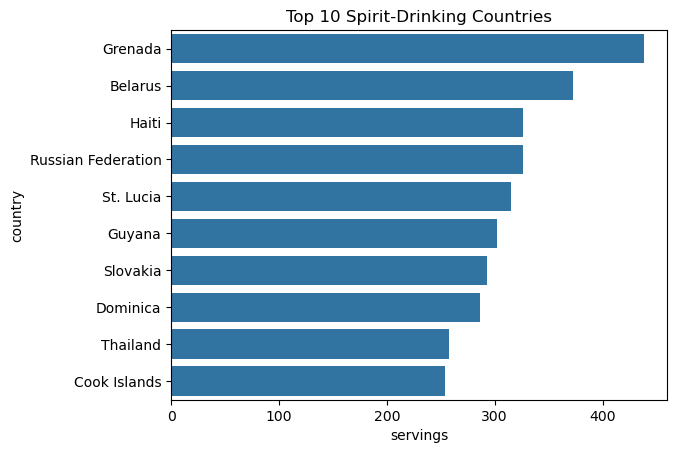

In [14]:
# Categorical plot #3: Who drinks the most spirits?
# Sort for the top 10 spirit-drinking countries:
top_10_spirits = (
    df_tidy[df_tidy["drink"] == "spirit"]
    .sort_values(by="servings", ascending=False)
    .head(10)
)

# Plot: 
sns.barplot(data=top_10_spirits, x="servings", y="country")
plt.title("Top 10 Spirit-Drinking Countries")
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [19]:
# Create a wide dataframe (reversing melt()):
# After reversing, we get country | wine | beer | spirit :
df_wide = df_tidy.pivot_table(
    index="country", # Rows.
    columns="drink", # New columns.
    values="servings" # Values to fill columns with.
)

# View results:
df_wide.head()

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0


In [20]:
# Clean up the index:
df_wide.columns.name = None # Because we used "drink" as the columns parameter, it becomes the column index name. 
df_wide = df_wide.reset_index()

# View results:
df_wide.head()

,country,beer,spirit,wine
0,Afghanistan,0.0,0.0,0.0
1,Albania,89.0,132.0,54.0
2,Algeria,25.0,0.0,14.0
3,Andorra,245.0,138.0,312.0
4,Angola,217.0,57.0,45.0
